## The project Goal

We want to answer:

"Can we predict the price of a house from its area?"

The mathematical model is:

$$ \hat y = wx+b $$

where:

\(x\) = house area
\(y\) = actual house price
\(w\) = weight/slope
\(b\) = bias/intercept
\(\hat y\) = predicted price

Input -

House area in square feet.

Output -

House price.

Loading the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load data

In [8]:
df = pd.read_csv('Data/Housing.csv')
df.head(10) # cheacking if the data is loaded correctly.

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
df.shape # checking the shape of the data
df.info() # checking the information of the data
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

## Inspect the data

In [10]:
# Missing values
df.isnull().sum() # checking the missing values in the data

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
df.duplicated().sum() # checking the duplicated values in the data

np.int64(0)

In [12]:
df.dtypes # checking the data types of the data

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

## Start building model with just one feature

In [13]:
x = df['area'] # Loading the area column as the independent variable
y = df['price'] # Loading the price column as the dependent variable

Plotting the graph

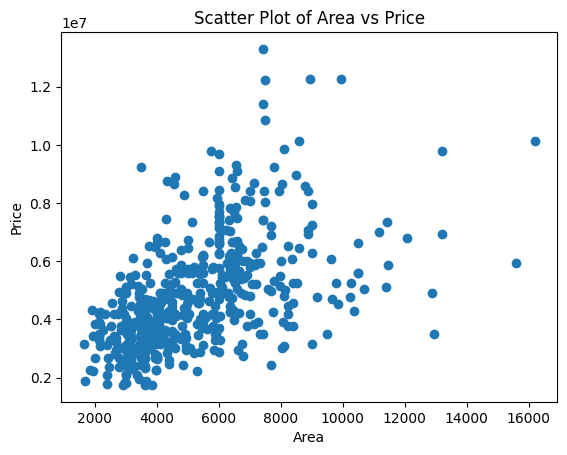

In [14]:
plt.scatter(x, y) # plotting the scatter plot of the data
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Scatter Plot of Area vs Price')
plt.show()

The plotted graph shows that there some linear relation between Area and a Price, so we can run linear regression algo. 
This phase is matter most as we have to know if the algo is suitable for the data.

### Now as the data inspaction done we can start the algo.

Preparing the X and Y
The feature and target.

In [19]:
X = df[[ 'area' ]].values
y = df['price'].values
print(X.shape) # checking the shape of the independent variable
print(y.shape) # checking the shape of the dependent variable

(545, 1)
(545,)


### Training and Test data split
If you train and test on the same data, the model can "memorize" the answers and look great — but fail on new data. 
So we have to split the data into two parts.
Note - we have to split in a way so that we get same split every time. Other wise we will get different results.

We will split into 80/20
```
80% → training
20% → testing

```

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Here the random_state helps to get the same split everytime.

For now we can pass the Standardization for one feature.